### Normal Squares, calculated gradients
-   This code creates a series of squares around the all exterior contours of a cell, normal to its outline, that can then be extracted into images
    - There is also a scoring function for judging outputs

### Basic Algorithm Outline:

-   Begin by extracting all external contours of a thresholded image
-   Then for every point along the contours, apply a Gaussian smoothing kernel to X and Y.
-   After this then apply np.gradient to X and Y to find dx and dy gradients
    - These can then be combined and normalized into tangent vectors and then normal vectors
-   Use these vectors and Kota's patch calcualation to find width of epithelium at each point
-   Then create sqaures all along the epithelium
    - This is currenlty done by creating a square at every set step rate and checking these for overlap against each other and allowing squares that do not overlap excessively with past squares
-   The remaining squares are stored and drawn on the original image


-   There is also an evaluation score that checks total coverage of the epithelium and number of blank pixles in the created mask


### Most Up-to_Date Features:
-   There is now one parameter in the function (overlap_thresh)
-   Smarter_squares checks all created squares for overlap with a proposed square, and keeps it if fulfilled
    - There are also size checks that approzimate the percentage of the epithelium covered by a patch
        - They are currently set to fall within 50% of contour area and 2% of area, attempting to avoid large and tiny patches

-   This algorithm currenlty just draws squares on the image, but the stored coordinates can be extracted to individual images

In [88]:
import numpy as np
import cv2
from shapely.geometry import Polygon
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt


#Read image and threshold for mask:
#This basic method works best with already cropped cells
#I have another at the bottom that is slightly better for cells with backgrounds
image1= cv2.imread("./images/epithelium_extraction/export/h2114155 h&e_ROI_2-labels.png")
#image1=cv2.imread("h2114153  h&e_ROI_1 Epithelia.png")
image1 = cv2.copyMakeBorder(
    image1,
    200, 200,  # Top, Bottom padding
    200, 200,  # Left, Right padding
    borderType=cv2.BORDER_CONSTANT,
    value=[255,255,255])
    #value=[0, 0, 0])  # Black color)_gray

image1_gray = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
whole_thresh1=cv2.threshold(image1_gray,240,255,cv2.THRESH_BINARY_INV)[1]


In [86]:
def get_external_contours(thresh):
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    masks = []
    parents = np.argwhere(hierarchy[0, :, 2] != -1).ravel()
    contour_indices = np.arange(0, hierarchy.shape[1], 1)
    while contour_indices.size != 0:
        current = parents[0]
        parents = np.delete(parents, 0)
        contour_indices = np.delete(contour_indices, np.argwhere(contour_indices == current))
        mask = np.zeros_like(thresh)
        cv2.drawContours(mask, contours, current, 255, 1)
        for j in np.argwhere(hierarchy[0, :, 3] == current).ravel():
            contour_indices = np.delete(contour_indices, np.argwhere(contour_indices == j))
            cv2.drawContours(mask, contours, j, 255, 1)
        masks.append(mask)
    external_contours = []
    for mask in masks:
        contour, hierarchy = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        external_contours.append(contour[0])
    return external_contours

def better_normals(contours,binary_image):
    #Initialize list for final normals
    all_normals=[]

    #Loop through all contours
    for contour in contours:
        #Reshape contour into point pairings
        points=contour.reshape(-1,2).astype(np.float32)
        
        #Store all X and Y points
        x_all,y_all=points[:,0],points[:,1]
        #Define sigma paramter(std for Gaussian Kernel from contour length)
        #Higher value of sigma means more aggressive smoothing
        sigma=len(contour)//90
        
        #Avoid dividing by 0
        if sigma==0:
            sigma=1

        #Apply Gaussian smoothing to X and Y values, attempting to remove noise from the contour
        x_smooth=gaussian_filter1d(x_all,sigma,mode='constant')
        y_smooth=gaussian_filter1d(y_all,sigma,mode='constant')

        #Calculate gradients of X and Y for use then finding the tangent
        dx=np.gradient(x_smooth)
        dy=np.gradient(y_smooth)


        #Combine the gradients for the tangent
        tangents=np.vstack((dx,dy)).T
        #Find vector norms of tangent vectors
        norms = np.linalg.norm(tangents, axis=1, keepdims=True)
        #Divide tangents by norms with numerical stability
        tangent_unit = tangents/(norms+1e-8)
        #Initialize normals
        normals=np.zeros_like(tangent_unit)
        #Rotate tangents into normals
        normals[:,0]=-tangent_unit[:,1]
        normals[:,1]=tangent_unit[:,0]

        all_normals.append(normals)



    return all_normals


def calculate_patch_corners(point, normal, binary_image, extension_factor=1.0, step_size=4, max_length=2048):
    """
    Calculate the corners of a square patch using epithelium width along the normal.

    Args:
        point (np.ndarray): The point on the contour.
        normal (np.ndarray): The normal vector at the point.
        binary_image (np.ndarray): Binary mask of the tissue.
        extension_factor (float): Factor to slightly enlarge the patch (e.g., 1.1 for 10% increase).
        step_size (int): Step size for checking tissue boundaries along the normal.
        max_length (int): Maximum distance to search for epithelium width.

    Returns:
        np.ndarray: The four corners of the square patch.
        int: The computed patch height.
    """
    height, width = binary_image.shape
    point = point.astype(int)

    # generating forward and backward points along the normal
    steps = np.arange(0, max_length, step_size)[:, None]
    points = np.clip(point - steps * normal, 0, [width - 1, height - 1]).astype(int)

    # extracting pixel values along the normal path
    values = binary_image[points[:, 1], points[:, 0]]

    # finding the first background pixel (where value == 0)
    stop = np.where(values == 0)[0]

    # computing distances
    width = stop[0] * step_size if stop.size > 0 else max_length

    # computing total epithelium width and adjust for stroma extension
    extended_length = int(width * extension_factor)
    half_size = extended_length // 2 

    # computing tangent vector (perpendicular to normal)
    tangent = np.array([-normal[1], normal[0]])

    # defining square corners (same logic as `calculate_square_corners`)
    corners = np.array([
        point + (tangent * half_size),
        point - (tangent * half_size),
        point - (tangent * half_size) - (normal * extended_length),
        point + (tangent * half_size) - (normal * extended_length)
    ])

    return corners, extended_length


def calculate_square_overlap(square1,square2):
    '''Calculate overlap ratio between squares'''

    square1=Polygon(square1)
    square2=Polygon(square2)

    if not square1.intersects(square2):
        return 0
    
    intersection_area=square1.intersection(square2).area
    smallest_area=min(square1.area,square2.area)
    return intersection_area/(smallest_area+1e-8)



def create_smarter_squares(contours,normals,binary_image,overlap_thresh):
    '''Create squares that meet overlap thresh with last square'''
    return_squares=[]
    #Loop over all contours and get corresponding normals to point
    for contour, contour_normals in zip(contours,normals):
        points=contour.reshape(-1,2)
        squares=[]
        last_square=None

        #Go over points, evaluating if next square's corner falls outside of range of last square
        for i,point in enumerate(points):

            corners,length=calculate_patch_corners(point,contour_normals[i],binary_image)

            #Prevent poorly sized squares
            #Finding rough area approximation in terms of patch length
            side_length = np.sqrt(cv2.contourArea(contour))
            #Approximately: Want squares less than 50% of contour area, and minimum of 2% area
            if length>side_length*.50:
                continue
            #Check to see if first square and check agaisnt last square to prevent long loop
            elif last_square is not None and calculate_square_overlap(last_square,corners)>overlap_thresh:
                continue
            #Check agasint all squares, prevents issues of larger patches covering thin sections of epithelium next to large ones 
            elif any(calculate_square_overlap(corners, square)>overlap_thresh for square in squares)==True:
                continue
        
            squares.append(corners)
            last_square=corners

        return_squares.append(squares)
    return return_squares

def draw_squares(image,squares_list,color=[255,0,0],thickness=20):
    '''Draw squares on image'''

    result=image.copy()

    for squares in squares_list:
        for square in squares:
            points=square.astype(np.int32)
            cv2.polylines(result,[points],isClosed=True,color=color,thickness=thickness)
        
    return result



def process_contours(image,binary_image,overlap_thresh=0.3):
    """
    Main function to process multiple contours and generate aligned squares along them.
    
    Args:
        image (np.ndarray): Original image
        binary_image (np.ndarray): Binary mask of the shapes
        overlap_thresh (float): Maximum allowed overlap between squares        
    Returns:
        tuple: (processed image, contours, squares_list)
    """
    contours=get_external_contours(binary_image)
    if not contours:
        return TypeError('No contours found')
    
    #Condition check for square creation
    #normals=calculate_contour_normals(contours,smoothing_size)
    normals=better_normals(contours,binary_image)
    final_squares_list=create_smarter_squares(contours,normals,binary_image,overlap_thresh=overlap_thresh)

    result = draw_squares(image,final_squares_list)
    
    return result, contours, final_squares_list





In [80]:
def check_metrics(binary_image,contours):
    '''Evaluate fit of normal squares using mask'''

    total_white_pixels=(binary_image>0).sum()
    squares_mask=np.zeros_like(binary_image,dtype=np.uint8)

    weight_coverage=0.8
    weight_black_pixels=0.2
    
    #For all squares in all contours, use them to create a mask
    for contour in contours:
        for square in contour:
            square=np.array(square,dtype=np.int32).reshape(-1,1,2)
            cv2.fillPoly(squares_mask,[square],255)

    mask_pixels=np.count_nonzero(squares_mask>0)

    #Find coverage and non-epitheliuem pixel values 

    covered_white_pixels=np.count_nonzero((squares_mask>0)&(binary_image>0))
    covered_black_pixels=np.count_nonzero((squares_mask>0)&(binary_image==0))

    total_coverage=(covered_white_pixels/total_white_pixels*100)
    black_pixel_percent=(covered_black_pixels/mask_pixels*100)
    score=weight_coverage*total_coverage+weight_black_pixels*(100-black_pixel_percent)
    
    return total_coverage,black_pixel_percent,score
        


Total Coverage: 92.05


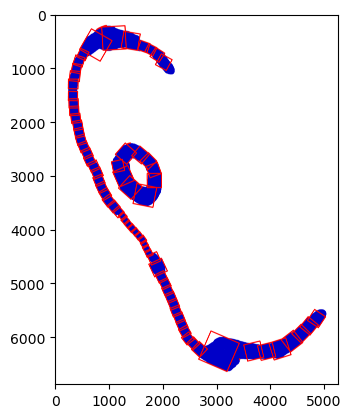

In [89]:
result,contours,final_squares=process_contours(image1,whole_thresh1,0.2)
total_coverage,_,_=check_metrics(whole_thresh1,final_squares)
plt.imshow(result)
print(f'Total Coverage: {total_coverage:.2f}')



Total Coverage: 92.54


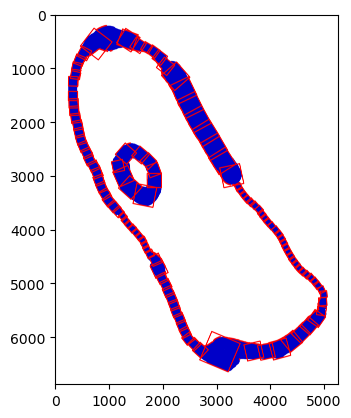

In [91]:
image2= cv2.imread("./images/epithelium_extraction/export/h2114155 h&e_ROI_2-labels_1.png")
image2 = cv2.copyMakeBorder(
    image2,
    200, 200,  # Top, Bottom padding
    200, 200,  # Left, Right padding
    borderType=cv2.BORDER_CONSTANT,
    value=[255,255,255])
    #value=[0, 0, 0])  # Black color)_gray

image2_gray = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)
whole_thresh2=cv2.threshold(image2_gray,240,255,cv2.THRESH_BINARY_INV)[1]

result,contours,final_squares=process_contours(image2,whole_thresh2,0.2)
total_coverage,_,_=check_metrics(whole_thresh2,final_squares)
plt.imshow(result)
print(f'Total Coverage: {total_coverage:.2f}')
